# Data Disclaimer

This dataset is synthetically generated based on the Credit Risk dataset from Kaggle and enriched with additional financial risk variables using SMOTENC. The results reflect patterns in simulated data and may not represent real-world credit behavior.

# Project Objectives




To perform an Exploratory Data Analysis to understand the characteristics of loan applicants. The goal is to uncover patterns and relationships between demographic profiles, financial status, and loan outcomes, rather than just predicting approval.

Project Scope and Research Questions:

*  Risk Assessment & Pricing Strategy (Questions 1, 2, 5, 6, 8) Analysis of credit scores, interest rates, income, and default history.

* Demographics & Borrower Profile (Questions 3, 4, 7, 9, 10) Analysis of age trends, gender, education, and borrower background.

* Loan Intent & Asset Profile (Questions 11, 12, 13) Analysis of home ownership types, loan purposes, and requested loan amounts.

* Complex Interactions & Data Validity (Questions 14, 15) Analysis of data reliability and the combined effect of housing status and loan intent.

Technologies Used:
* Python (Analysis Core)
* Pandas (Data Manipulation)
* Seaborn & Matplotlib (Visualization)
* Jupyter Notebook (Environment)

# Load Data

In [ ]:
import pandas as pd
import kagglehub

In [ ]:
df = pd.read_csv("/content/loan_data.csv")

In [ ]:
print("Data shape:", df.shape)

Data shape: (45000, 14)


#Exploratory Data Analysis

In [ ]:
df.head(3)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
df.dtypes

,0
person_age,float64
person_gender,object
person_education,object
person_income,float64
person_emp_exp,int64
person_home_ownership,object
loan_amnt,float64
loan_intent,object
loan_int_rate,float64
loan_percent_income,float64


Note: From the data types, we can see that most features are numerical (int64/float64), while a few categorical features are object.

# Data Dictionary

1.	age: Age of the customer in years
2.	person_gender: Gender of the customer

  •	0 = female

  •	1 = male
3.	person_education: Education level of the customer

  •	High School

  •	Associate

  •	Bachelor

  •	Master

  •	Doctorate

4.	person_income: Annual income of the customer
5.	person_emp_exp: Years of employment experience
6.	person_home_ownership: Home ownership status of the customer

  •	OWN

  •	ERNT

  •	MORTGAGE

  •	OTHER
7.	loan_amnt: Amount of loan requested
8.	loan_intent: Purpose of the loan

  •	PERSONAL

  •	EDUCATION

  •	MEDICAL

  •	VENTURE

  •	HOMEIMPROVEMENT

  •	DEBTCONSOLIDATION

  •	OTHER

9.	loan_int_rate: Interest rate of the loan
10.	loan_percent_income: Loan amount as a percentage of income
11.	cb_person_cred_hist_length: Length of the customer’s credit history
12.	credit_score: Customer's credit score
13.	previous_loan_defaults_on_file: Previous loan defaults on record

   •	Yes

    •	No

14.	loan_status: Target variable: loan approved or rejected

    •	0 = Rejected

    •	1 = Approved


# Rename columns for the sake of clarity

The feature names in the dataset are abbreviated and difficult to understand. Therefore, to improve readability and clarity, we will rename the columns of the DataFrame below.

In [ ]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [ ]:
# Renames columns from key to value and checks that all exist.

df = df.rename(
    columns = {'person_income':'person_annual_income',
               'person_emp_exp':'person_employment_experience',
               'loan_amnt':'loan_amount',
               'loan_int_rate':'loan_interest_rate',
               'loan_percent_income':'loan_percent_of_income',
               'cb_person_cred_hist_length':'credit_history_years',
               'previous_loan_defaults_on_file':'previous_loan_defaults'},
    errors="raise")

In [ ]:
df.columns

Index(['person_age', 'person_gender', 'person_education',
       'person_annual_income', 'person_employment_experience',
       'person_home_ownership', 'loan_amount', 'loan_intent',
       'loan_interest_rate', 'loan_percent_of_income', 'credit_history_years',
       'credit_score', 'previous_loan_defaults', 'loan_status'],
      dtype='object')

# Null values

In [ ]:
df.isna().sum()   # no null values

,0
person_age,0
person_gender,0
person_education,0
person_annual_income,0
person_employment_experience,0
person_home_ownership,0
loan_amount,0
loan_intent,0
loan_interest_rate,0
loan_percent_of_income,0


No null values found in the dataset.

# Data Duplicated

In [ ]:
df.duplicated().sum()   # no duplicates

np.int64(0)

No duplicates found in the dataset.

# Data Cleaning – Age Feature

During the data exploration phase, unrealistic age values (age > 100) were detected. Since such values are not plausible, the corresponding records were removed to prevent distortion of the analysis.

In [ ]:
# Check minimum and maximum values to detect anomalies
df["person_age"].agg(["max","min"]).to_frame()

,person_age
max,144.0
min,20.0


Step 1: Identify unrealistic age values

In [ ]:
# Ages above 100 are considered extreme outliers in this dataset
num_age_outliers = (df['person_age'] > 100).sum()

print(f"Number of age outliers (age > 100): {num_age_outliers}")

Number of age outliers (age > 100): 7


Step 2: Remove extreme age outliers

Based on the analysis above, we identified 7 rows with an unrealistic age value (age > 100).

These rows were removed to improve data quality.

In [ ]:
initial_size = len(df)

df = df[df['person_age'] <= 100]

final_size = len(df)

print(f"Rows removed due to unrealistic age values: {initial_size - final_size}")
print(f"Dataset size after cleaning: {final_size}")

Rows removed due to unrealistic age values: 7
Dataset size after cleaning: 44993


Step 3: Validation

In [ ]:
# Confirm no unrealistic age values remain
(df['person_age'] > 100).sum()

np.int64(0)

# Grouping Features (by data type)

As shown above, the dataset contains three data types: object, integer, and float. In the next step, we will group the variables according to their data type.

In [ ]:
df.dtypes

,0
person_age,float64
person_gender,object
person_education,object
person_annual_income,float64
person_employment_experience,int64
person_home_ownership,object
loan_amount,float64
loan_intent,object
loan_interest_rate,float64
loan_percent_of_income,float64


In [ ]:
## Numerical features – continuous or discrete numbers
df_numerical = df[['person_age',
                'person_annual_income',
                'person_employment_experience',
                'loan_amount',
                'loan_interest_rate',
                'loan_percent_of_income',
                'credit_history_years',
                'credit_score']]

# Binary categorical – 2 possible values (Yes/No, 0/1)
df_binary_cat = df[['person_gender', 'previous_loan_defaults', 'loan_status']]

# Nominal categorical – multiple categories, no order
df_nominal_cat = df[['person_education', 'person_home_ownership', 'loan_intent']]

# All categorical – binary + nominal
df_categorical = df_numerical + df_binary_cat

# Target Distribution

The target variable is highly imbalanced, with only ~22% of loans approved and ~78% rejected.

This indicates that the likelihood of loan approval is relatively low.

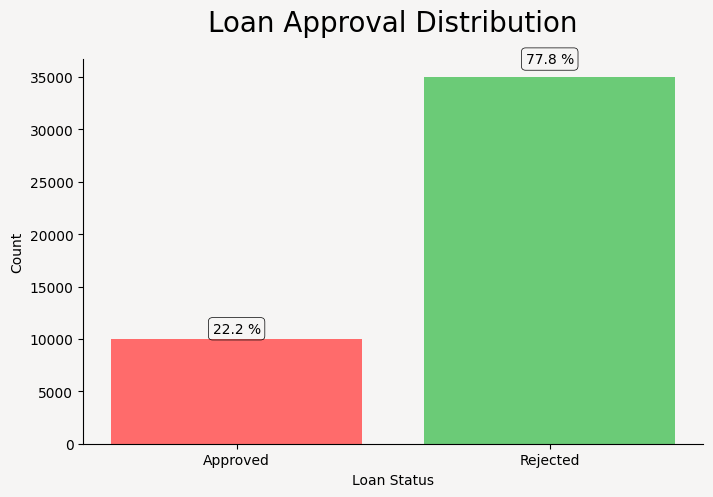

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count approved and rejected loans
approved_count = df['loan_status'].sum()   # Count all loans where loan_status=1
rejected_count = len(df) - approved_count  # The rest are Rejected

# Prepare the values and labels for the bars
values = [approved_count, rejected_count]  # Numbers for each bar
categories = ['Approved', 'Rejected']      # Labels for X-axis

# Choose colors (Pink = Approved, Turquoise = Rejected)
colors = ['#FF6B6B', '#6BCB77']

# Create the figure and set background
plt.figure(figsize=(8,5), facecolor='#F6F5F4')
bars = plt.bar(categories, values, color=colors)
plt.gca().set_facecolor('#F6F5F4')  # Background color for the plot area itself

# Add percentages on top of each bar with a small box
# - height: height of the bar
# - p.get_x() + p.get_width()/2: horizontal center of the bar
# - height * 1.01: slightly above the bar
# - ha='center', va='bottom': center horizontally, above vertically
# - bbox: creates a small black-bordered box around the text
total = sum(values)
for p in bars:
    height = p.get_height()
    plt.text(
        p.get_x() + p.get_width()/2,
        height * 1.03,
        '{:1.1f} %'.format((height/total)*100),
        ha='center',
        va='bottom',
        bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.5)
    )

# Title, font size, slightly above graph
plt.title('Loan Approval Distribution', fontsize=20, y=1.05)
plt.xlabel('Loan Status', fontsize=10)       # X-axis label
plt.ylabel('Count', fontsize=10)  # Y-axis label

# Remove top and right borders for cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

# Numerical Features
Statistical summary
For the numerical features we can apply the handy pandas data.describe() method and get the global statistical summary. Key figures are highlighted below.

In [ ]:
df_numerical.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,44993.0,27.748428,5.909737,20.00,24.00,26.00,30.00,94.00
person_annual_income,44993.0,79908.447581,63322.132349,8000.00,47195.00,67046.00,95778.00,2448661.00
person_employment_experience,44993.0,5.394528,5.927159,0.00,1.00,4.00,8.00,76.00
loan_amount,44993.0,9583.176761,6314.802655,500.00,5000.00,8000.00,12237.00,35000.00
loan_interest_rate,44993.0,11.006448,2.978985,5.42,8.59,11.01,12.99,20.00
loan_percent_of_income,44993.0,0.139736,0.087207,0.00,0.07,0.12,0.19,0.66
credit_history_years,44993.0,5.866557,3.877167,2.00,3.00,4.00,8.00,30.00
credit_score,44993.0,632.585713,50.402411,390.00,601.00,640.00,670.00,784.00


Statistical summary of the numerical features

* Age: The average age is 27.7 years, ranging from 20 to 94. Most applicants (75%) are aged 30 or younger, indicating a primarily young audience.

* Annual Income: The average income is 79,908.
but the median is 67,046. This gap shows that a few high-income earners (up to 2.4M) are pulling the average up.

* Employment Experience: On average, applicants have 5.4 years of work experience. The values range from 0 to 76 years.

* Loan Amount: The average loan requested is 9,583, with requests ranging from a minimum of 500 to a maximum of 35,000.

* Interest Rate: The average rate is 11%, though it varies significantly from 5.4% to 20% based on the risk profile.

* Loan to Income Ratio: On average, the loan takes up 14% of the applicant's annual income. However, some cases reach a high risk level of 66%.

* Credit History: The average credit history length is 5.8 years, reaching up to 30 years for long term credit users.

* Credit Score: The average score is 632.5, with most applicants falling between 601 and 670. This is generally categorized as a "Fair" credit rating.





In the following sections, I will focus on analyzing the interactions between key numerical features to uncover the patterns driving the bank's decision-making process.

# Interest Rate Distribution by Loan Status

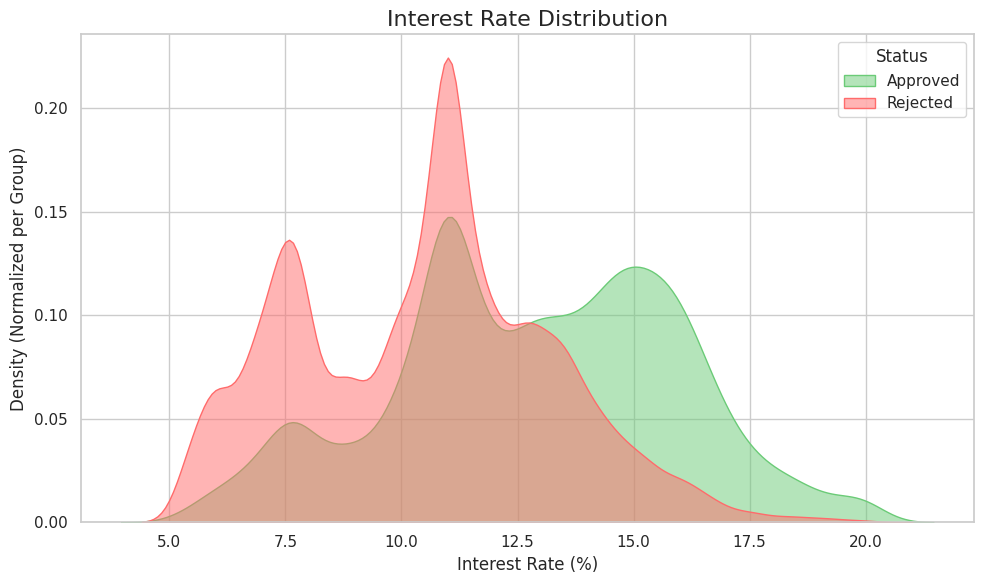

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Design and Color Setup
# Define a custom color palette for consistency:


custom_palette = {0: '#FF6B6B',     # 0 (Rejected) = Pink
                  1: '#6BCB77'}     # 1 (Approved) = Green

# Set a clean theme (white background with grid)
sns.set_theme(style="whitegrid", palette="muted")

plt.figure(figsize=(10, 6))

# Step 2: Create Density Plot
# Objective: Compare the *distribution* of interest rates between Approved and Rejected,
# while neutralizing the effect of class imbalance (since there are ~4x more rejections).
ax = sns.kdeplot(
    data=df,
    x='loan_interest_rate',  # The variable to analyze (X-axis)
    hue='loan_status',       # Grouping variable (Colors)
    fill=True,               # Fill the area under the curve
    palette=custom_palette,  # Use our defined colors
    alpha=0.5,               # Transparency (to visualize overlap)

    # common_norm=False:
    # If True (default), scaling is based on total count, which would flatten
    # the minority class ('Approved') curve, making it hard to see.
    # Setting this to False normalizes each group independently to 100%.
    # This allows us to compare SHAPE (behavior) rather than COUNT (volume).
    common_norm=False
)

# Step 3: Final Styling and Labels
# Manually update the Legend to show 'Approved'/'Rejected' instead of 0/1
plt.legend(title='Status', labels=['Approved', 'Rejected'], loc='upper right')

# Add clear titles
plt.title('Interest Rate Distribution', fontsize=16)
plt.xlabel('Interest Rate (%)', fontsize=12)
plt.ylabel('Density (Normalized per Group)', fontsize=12)

plt.tight_layout()
plt.show()

The graph shows that approved loans usually have higher interest rates than rejected ones (seen as a shift to the right).

This suggests the bank uses 'risk based pricing'. Instead of simply rejecting risky applicants, the bank approves them at a higher interest rate to balance the risk

In [ ]:
df_credit_status = df[['loan_interest_rate', 'loan_status']]
df_credit_status.corr()

,loan_interest_rate,loan_status
loan_interest_rate,1.000000,0.332046
loan_status,0.332046,1.000000


Rejected applicants might have been approved if they agreed to pay a higher interest rate, because this would balance the risk for the bank. Indeed, my correlation analysis confirms this: as the interest rate increases, the chance of approval also increases.

# Age vs. Loan Approval


Question: Does the probability of loan approval follow a linear path with age?

Feature Engineering: Creating Age Groups

I grouped ages into categories instead of using exact numbers.

* Reason: Financial habits don't change in a straight line; they depend on life stages.

* Benefit: This helps us see clear trends (like the stability of older age) and reduces data noise."

In [ ]:
# Categorize age into logical groups for better analysis
df['age_group'] = pd.cut(
    df['person_age'],
    bins=[20, 25, 30, 40, 50, 100],
    labels=['20-25',      # 20-25 (Young / Students)
            '26-30',      # 26-30 (Early Career)
            '31-40',      # 31-40 (Established)
            '41-50',      # 41-50 (Senior Professionals)
            '50+'],       # 50+ (Older Adults)
    include_lowest=True
)

# Optional: Check the first few rows to see the new column
print(df[['person_age', 'age_group']].head())

   person_age age_group
0        22.0     20-25
1        21.0     20-25
2        25.0     20-25
3        23.0     20-25
4        24.0     20-25


In [ ]:
# Calculate the percentage of approved loans for each age group
approval_rates = df.groupby('age_group')['loan_status'].mean() * 100

print("Approval Rates by Age Group:")
print(approval_rates)

Approval Rates by Age Group:
age_group
20-25    23.394159
26-30    21.485886
31-40    20.817165
41-50    20.648577
50+      25.856698
Name: loan_status, dtype: float64


/tmp/ipython-input-3479067552.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approval_rates = df.groupby('age_group')['loan_status'].mean() * 100


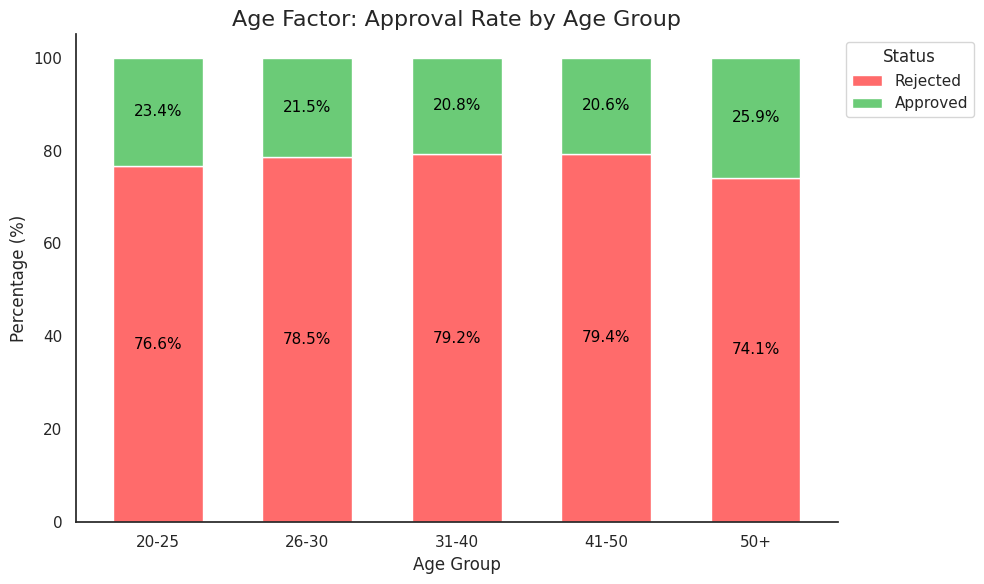

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate percentages using Crosstab
# normalize='index' ensures rows sum to 100%
crosstab_age = pd.crosstab(df['age_group'], df['loan_status'], normalize='index') * 100

# Step 2: Plotting
custom_palette = ['#FF6B6B', '#6BCB77'] # Pink = Rejected, Green = Approved
sns.set_theme(style="white")

# Create the Stacked Bar Chart
ax = crosstab_age.plot(kind='bar', stacked=True, color=custom_palette, figsize=(10, 6), width=0.6)

# Step 3: Styling
plt.title('Age Factor: Approval Rate by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)

# Add percentage labels to the center of each bar segment
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=11, color='black')

# Update the Legend
plt.legend(title='Status', labels=['Rejected', 'Approved'], loc='upper left', bbox_to_anchor=(1, 1))

sns.despine() # Remove top and right borders
plt.tight_layout()
plt.show()

Graph Explanation: The data reveals a distinct U-shaped trend: Approval rates start relatively high for young applicants (ages 20-25), drop to their lowest point during mid-life (ages 26-50), and peak significantly for applicants over 50.

Key Insight: The bank appears to view middle aged applicants as a higher risk group due to peak financial burdens (such as mortgages and family expenses). In contrast, older applicants (who are financially established) and younger applicants (with less existing debt) enjoy higher approval rates.

While the graph shows a higher approval rate for the 50+ age group, let's examine the sample sizes to ensure reliability.

In [ ]:
import pandas as pd

# 1. Calculate the volume (count) and approval rate (mean) for each age group
age_table = df.groupby('age_group')['loan_status'].agg(['count', 'mean']).reset_index()

# 2. Define the logical order for age groups (to prevent incorrect alphabetical sorting)
custom_order = ['20-25', '26-30', '31-40', '41-50', '50+']
age_table['age_group'] = pd.Categorical(age_table['age_group'], categories=custom_order, ordered=True)
age_table = age_table.sort_values('age_group')

# 3. Rename columns for professional presentation
age_table.columns = ['Age Group', 'Total Applicants', 'Approval Rate']

# 4. Apply formatting
clean_table = age_table.style.format({
    'Approval Rate': '{:.1%}',      # Display as percentage with 1 decimal place (e.g., 25.9%)
    'Total Applicants': '{:,}'      # Add thousands separator (e.g., 1,500)
}).hide(axis='index')               # Hide the default row numbers (index)

# 5. Display the table
clean_table

/tmp/ipython-input-2755834510.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_table = df.groupby('age_group')['loan_status'].agg(['count', 'mean']).reset_index()


Age Group,Total Applicants,Approval Rate
20-25,"20,441",23.4%
26-30,"13,958",21.5%
31-40,"8,762",20.8%
41-50,"1,511",20.6%
50+,321,25.9%


Although the '50+' group is the smallest (only 321 applicants), it has the highest approval rate (25.9%).

This suggests that older applicants are a 'Niche Quality' group: they apply less often, but when they do, they tend to be slightly more financially stable and safer for the bank.

# The Age "U-Curve"

The graph reveals a clear **"U-shaped" trend**:
* **Young Adults (20-25):** High approval rates, likely due to smaller loan requests or student programs.
* **The "Middle Age Dip" (30-40):** Approval rates drop. This group often faces high expenses (like mortgages and family costs), making them riskier to the bank.
* **Older Adults (50+):** The rates rise again, reflecting the financial stability and assets accumulated over time.

In [ ]:
approval_stats = df.groupby('age_group')['loan_status'].mean() * 100
approval_stats

/tmp/ipython-input-2113956014.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approval_stats = df.groupby('age_group')['loan_status'].mean() * 100


,loan_status
age_group,
20-25,23.394159
26-30,21.485886
31-40,20.817165
41-50,20.648577
50+,25.856698


/tmp/ipython-input-2964506307.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approval_stats = df.groupby('age_group')['loan_status'].mean() * 100


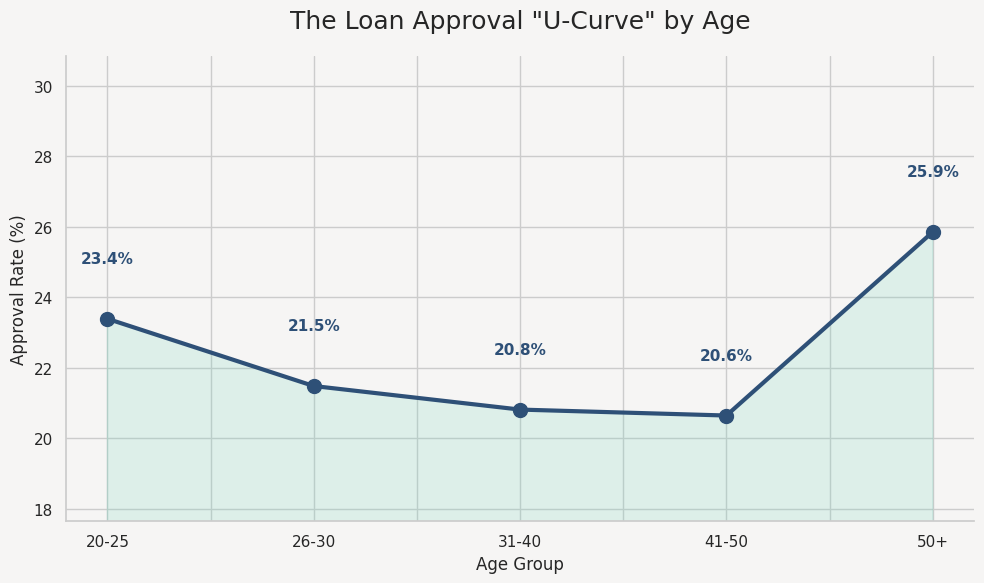

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Note: Assuming 'df' already contains the 'age_group' column.

# Step 1: Calculate Approval Rates
approval_stats = df.groupby('age_group')['loan_status'].mean() * 100

# Step 2: Initialize the Plot
# We use 'whitegrid' for the grid lines.
sns.set_style("whitegrid")

# Set the figure background (the outer frame) to grey
plt.figure(figsize=(10, 6), facecolor='#F6F5F4')

# Get the current axes (the chart area itself) and force it to be grey as well
ax = plt.gca()
ax.set_facecolor('#F6F5F4') # This ensures the blue fill blends with the grey background

# Step 3: Create the Line Plot & Fill Area
# Plot the main trend line
approval_stats.plot(kind='line', marker='o', color='#2E5077', linewidth=3, markersize=10, ax=ax)

# Fill the area under the line
plt.fill_between(range(len(approval_stats)), approval_stats, color='#79D7BE', alpha=0.2)

# Step 4: Add Data Labels
for i, rate in enumerate(approval_stats):
    plt.text(
        x=i,
        y=rate + 1.5,
        s=f'{rate:.1f}%',
        ha='center', va='bottom',
        fontweight='bold', fontsize=11, color='#2E5077'
    )

# Step 5: Styling
plt.title('The Loan Approval "U-Curve" by Age', fontsize=18, pad=20)
plt.ylabel('Approval Rate (%)', fontsize=12)
plt.xlabel('Age Group', fontsize=12)

# Adjust limits for better visibility
plt.ylim(approval_stats.min() - 3, approval_stats.max() + 5)

sns.despine()
plt.tight_layout()
plt.show()

# The Credit Score Anomaly

Question: How does credit score influence loan approval decisions?

Surprisingly, analysis shows that Credit Score has no predictive power in this dataset. We found almost identical scores for both approved and rejected loans.

In [ ]:
df_credit_status = df[['credit_score', 'loan_status']]
df_credit_status.corr()

,credit_score,loan_status
credit_score,1.000000,-0.007409
loan_status,-0.007409,1.000000


In [ ]:
# Calculate Median Credit Scores

# Calculate the median for Rejected loans (loan_status = 0)
median_rejected = df[df['loan_status'] == 0]['credit_score'].median()

# Calculate the median for Approved loans (loan_status = 1)
median_approved = df[df['loan_status'] == 1]['credit_score'].median()

# Print the results
print(f"Median Score - Rejected (0): {median_rejected}")
print(f"Median Score - Approved (1): {median_approved}")

Median Score - Rejected (0): 640.0
Median Score - Approved (1): 639.0


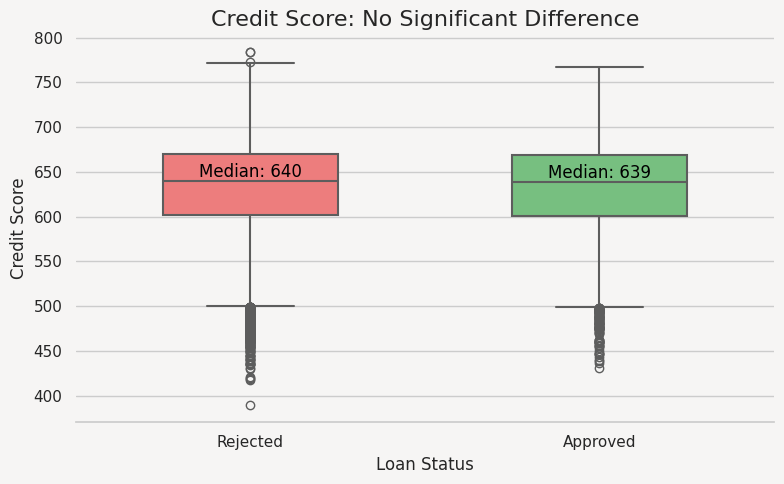

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Visual Analysis (Box Plot)
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5), facecolor='#F6F5F4')

# Define colors: Red for Rejected (0), Green for Approved (1)
# Using traffic light colors to clearly distinguish the groups
traffic_palette = {0: '#FF6B6B', 1: '#6BCB77'}

# Create the Box Plot
# This helps us see that the medians are actually at the same level
ax = sns.boxplot(
    x='loan_status',
    y='credit_score',
    hue='loan_status',
    data=df,
    palette=traffic_palette,
    width=0.5,       # Elegant width
    linewidth=1.5,   # Clear lines
    legend=False     # Redundant legend removed
)

# Step 2: Styling and Labels
plt.gca().set_facecolor('#F6F5F4') # Match plot background
plt.title('Credit Score: No Significant Difference', fontsize=16)
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Credit Score', fontsize=12)

# Clear X-axis labels
plt.xticks([0, 1], ['Rejected', 'Approved'])

# Add the Median values text on the plot to emphasize the finding
plt.text(0, median_rejected, f'Median: {int(median_rejected)}', color='black', ha='center', va='bottom')
plt.text(1, median_approved, f'Median: {int(median_approved)}', color='black', ha='center', va='bottom')

sns.despine(left=True) # Clean look
plt.tight_layout()
plt.show()

Insight: This anomaly contradicts standard banking logic. Since this is synthetic data, the generation process may not have weighted this feature, as it does not appear to differentiate between approved and rejected loans in our analysis.

# Median Split Analysis: Income vs. Experience Trade-off

What we did: We divided the applicants into two specific groups based on the median of their income and experience.

Approval Rates by Profile:
                          Profile  loan_status
0  High Income / \nLow Experience    12.927432
1  Low Income / \nHigh Experience    30.482820


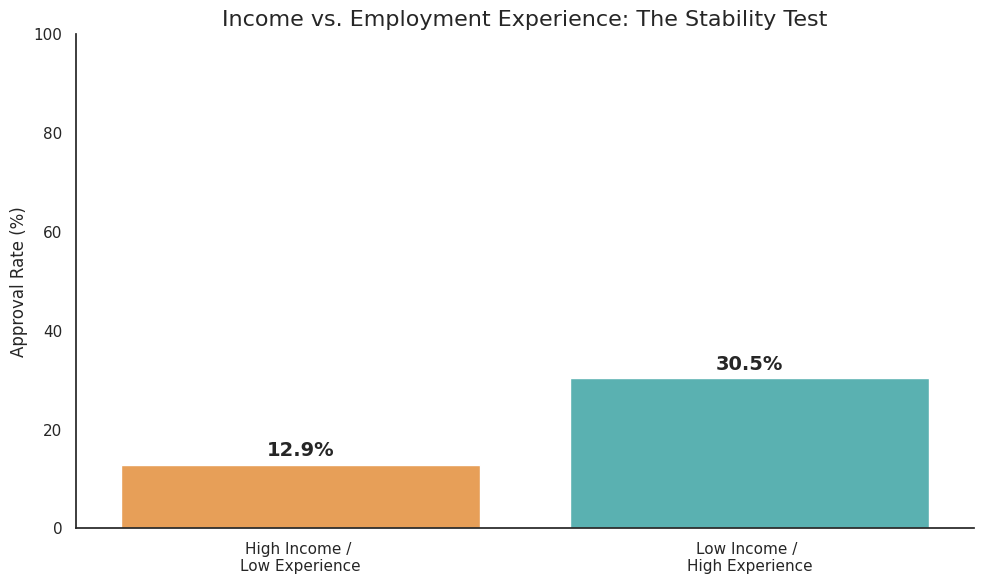

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define Thresholds
# We use the median to split the data into "High" and "Low" groups.
median_income = df['person_annual_income'].median()
median_experience = df['person_employment_experience'].median()

# Step 2: Create Specific Applicant Profiles
# Profile A: "High Income / Low Experience"
# These applicants earn a lot but have just started working.
group_new_money = df[
    (df['person_annual_income'] > median_income) &
    (df['person_employment_experience'] <= median_experience)
].copy()
group_new_money['Profile'] = 'High Income / \nLow Experience'

# Profile B: "Low Income / High Experience"
# These applicants earn less but have a stable, long-term job.
group_steady = df[
    (df['person_annual_income'] <= median_income) &
    (df['person_employment_experience'] > median_experience)
].copy()
group_steady['Profile'] = 'Low Income / \nHigh Experience'

# Step 3: Combine and Calculate Approval Rates
# Combine the two groups into one DataFrame
comparison_df = pd.concat([group_new_money, group_steady])

# Calculate the percentage of approved loans (mean * 100)
approval_rates = comparison_df.groupby('Profile')['loan_status'].mean().reset_index()
approval_rates['loan_status'] = approval_rates['loan_status'] * 100

# Print the exact numbers to the console
print("Approval Rates by Profile:")
print(approval_rates)

# Step 4: Plot the Bar Chart
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# Define colors: Orange for High Income, Turquoise for High Experience
colors = {'High Income / \nLow Experience': '#FF9F40',
          'Low Income / \nHigh Experience': '#4BC0C0'}

# Create the bar chart
# Note: We use hue='Profile' and legend=False to avoid Seaborn warnings
ax = sns.barplot(
    x='Profile',
    y='loan_status',
    hue='Profile',
    data=approval_rates,
    palette=colors,
    legend=False
)

# Step 5: Final Styling and Labels
plt.title('Median Split Analysis: Income vs. Experience Trade-off', fontsize=16)
plt.ylabel('Approval Rate (%)', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylim(0, 100) # Set Y-axis scale from 0% to 100%

# Add the percentage labels on top of the bars
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', padding=3, fontsize=14, weight='bold')

sns.despine() # Remove the top and right borders for a clean look
plt.tight_layout()
plt.show()

The Method: We compared two specific groups based on the median (the middle value):
1. High Income / Low Experience: Income above the median, but Experience below the median.

2. Low Income / High Experience: Income below the median, but Experience above the median.


Key Finding: Applicants with experience above the median and income below the median are almost 2.5 times more likely to be approved than applicants with income above the median and experience below the median.

Conclusion: When comparing these specific cases around the median, the bank clearly prioritizes job stability over a high salary.

# Binary categorical

The following Pie Charts visualize the binary features, serving as the basis for the analysis and conclusions below:

Loan Status:

The dataset shows a clear class imbalance. Only 22.2% of the loan applications are Approved (Class 1), while 77.8% are Rejected (Class 0). This indicates a conservative lending policy.







Previous Defaults:

Surprisingly, 50.8% of the applicants have a history of defaulting on loans. This is an unusually high ratio for a general population and is likely the primary driver behind the high rejection rate observed in the target variable.





Gender:

The gender distribution is fairly balanced, with 55.2% Male and 44.8% Female applicants. It reduces the risk of inherent demographic bias compared to datasets that are heavily skewed toward one gender.

In [ ]:
cols_to_check = ['person_gender', 'previous_loan_defaults', 'loan_status']

for col in cols_to_check:
    print(f"\nAnalyzing: {col}")

    # 1. Calculate Absolute Frequency (Raw Counts)
    counts = df[col].value_counts()

    # 2. Calculate Relative Frequency (Percentages)
    # normalize=True converts counts to fractions (0 to 1), multiplied by 100 for percentage
    percents = df[col].value_counts(normalize=True) * 100

    # 3. Create a temporary DataFrame for clean display
    # This combines counts and percentages side-by-side
    verification_df = pd.DataFrame({
        'Count': counts,
        'Percentage': percents.map('{:.1f}%'.format) # Format to 1 decimal place with '%' sign
    })

    # Print the summary table and a separator line
    print(verification_df)
    print("-" * 30)


Analyzing: person_gender
               Count Percentage
person_gender                  
male           24836      55.2%
female         20157      44.8%
------------------------------

Analyzing: previous_loan_defaults
                        Count Percentage
previous_loan_defaults                  
Yes                     22856      50.8%
No                      22137      49.2%
------------------------------

Analyzing: loan_status
             Count Percentage
loan_status                  
0            34993      77.8%
1            10000      22.2%
------------------------------


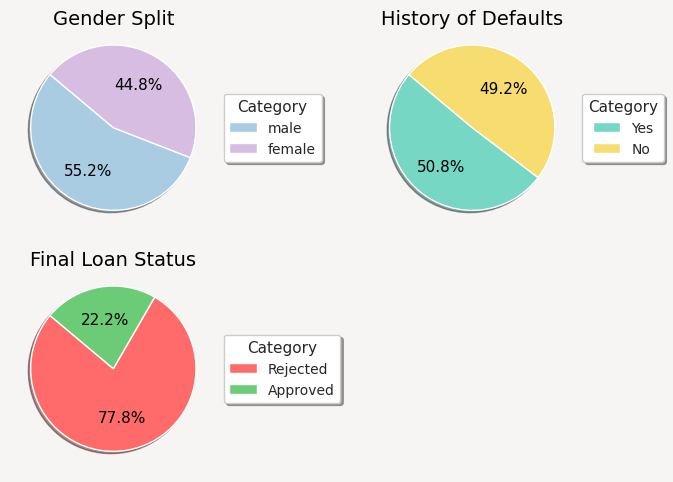

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Data Preparation
# We create a copy of the dataframe to keep the original numeric data intact
# for machine learning models later.
plot_df = df_binary_cat.copy()

# Convert binary values (0/1) to readable labels for the visualization
# This makes the chart self explanatory without needing to guess what '0' means.
if 'loan_status' in plot_df.columns:
    plot_df['loan_status'] = plot_df['loan_status'].map({0: 'Rejected', 1: 'Approved'})

# Define the columns to plot and their corresponding display titles
cols = ['person_gender', 'previous_loan_defaults', 'loan_status']
titles = ['Gender Split', 'History of Defaults', 'Final Loan Status']

# Step 2: Color Configuration
# Define distinct color palettes for each variable to avoid visual confusion.

# Palette 1: Gender (Soft Blue & Purple)
palette_gender = ['#A9CCE3', '#D7BDE2']
# Palette 2: Defaults (Teal & Yellow - distinct from gender)
palette_defaults = ['#76D7C4', '#F7DC6F']
# Palette 3: Loan Status (Red & Green)
# Red for Rejected, Green for Approved.
palette_status = ['#FF6B6B', '#6BCB77']

# Store palettes in a list to access them inside the loop
all_palettes = [palette_gender, palette_defaults, palette_status]

# Step 3: Layout Setup
# Initialize the figure.
fig = plt.figure(figsize=(7, 5), facecolor='#F6F5F4')

# GridSpec allows us to customize the subplot arrangement.
# We create a 2x2 grid.
gs = fig.add_gridspec(2, 2)

# Assign axes to specific grid positions:
ax1 = fig.add_subplot(gs[0, 0]) # Top-Left: Gender
ax2 = fig.add_subplot(gs[0, 1]) # Top-Right: Defaults
ax3 = fig.add_subplot(gs[1, 0]) # Bottom-Left: Loan Status

# Note: gs[1, 1] (Bottom-Right) is left empty intentionally to keep the layout clean.

# Group axes into a list for iteration
axes_list = [ax1, ax2, ax3]

# Step 4: Plotting Loop
for i, ax in enumerate(axes_list):
    col = cols[i]

    # Calculate value counts for the current column
    counts = plot_df[col].value_counts()
    num_slices = len(counts)

    # Create the Pie Chart
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=None,             # Labels are hidden on the pie (moved to legend)
        autopct='%1.1f%%',       # Show percentages with 1 decimal place
        startangle=140,          # Rotate start for better aesthetic alignment
        colors=all_palettes[i][:num_slices], # Apply the specific palette
        shadow=True,             # Add 3D shadow effect
        radius=1.0               # Standard radius size
    )

    # Style the percentage text inside the pie slices
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontsize(11)

    # Set the Title
    ax.set_title(
        titles[i],
        fontsize=14,
        color='Black',
        y=0.96 # Slightly lower position to sit tight above the chart
    )

    # Configure the Legend
    # Placed outside the chart to the right using 'bbox_to_anchor'
    ax.legend(
        wedges,
        counts.index,
        title="Category",
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1), # Anchor to the right side of the plot area
        fontsize=10,
        title_fontsize=11,
        frameon=True,
        shadow=True
    )

# Adjust layout to prevent overlap and show the plot
plt.tight_layout()
plt.show()

# How common are previous loan defaults, and how do they affect loan approval?

In this dataset, previous loan defaults are relatively common, with a nearly balanced distribution between applicants with and without a prior default history. However, the impact of this factor on loan outcomes is absolute: while applicants with a clean history see a 45.2% approval rate, those with any prior default face a 0% approval rate. This identifies previous default history not just as a significant variable, but as the absolute decisive factor in the loan approval process.

/tmp/ipython-input-239310844.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  values = [default_counts[0], default_counts[1]]


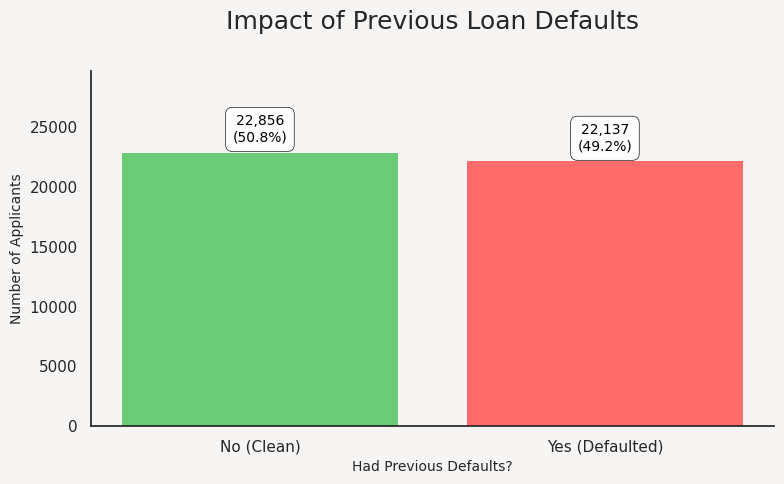

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculation
default_counts = df['previous_loan_defaults'].value_counts()
total = len(df)

# Prepare categories and values (0 = No, 1 = Yes)
categories = ['No (Clean)', 'Yes (Defaulted)']
values = [default_counts[0], default_counts[1]]

# Colors: Green for Clean History, Red for Past Defaults
colors = ['#6BCB77', '#FF6B6B']

# 2. Setup Figure and Background
plt.figure(figsize=(8, 5), facecolor='#F6F5F4')
ax = plt.gca()
ax.set_facecolor('#F6F5F4')

# 3. Create the Bars
bars = ax.bar(categories, values, color=colors, linewidth=0)

# 4. Add Text Boxes (Snug to the top)
for p in bars:
    height = p.get_height()
    percentage = (height / total) * 100
    label = f'{int(height):,}\n({percentage:.1f}%)'

    ax.text(
        p.get_x() + p.get_width()/2,
        height * 1.03,
        label,
        ha='center',
        va='bottom',
        fontsize=10,
        color='black',
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.5',
            linewidth=0.5,
            alpha=0.9
        )
    )

# 5. Titles and Axes (Y-axis is BACK)
plt.title('Impact of Previous Loan Defaults', fontsize=18, pad=30)
plt.xlabel('Had Previous Defaults?', fontsize=10)
plt.ylabel('Number of Applicants', fontsize=10)

# 6. Cleaning the Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Keeping the left spine (Y-axis)
ax.spines['left'].set_visible(True)

# 7. Setting the Y-limit precisely
# This ensures the boxes are visible but the axis doesn't overshoot
plt.ylim(0, max(values) * 1.3)

plt.tight_layout()
plt.show()

/tmp/ipython-input-3526581977.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  values = [approval_rates[0], approval_rates[1]]


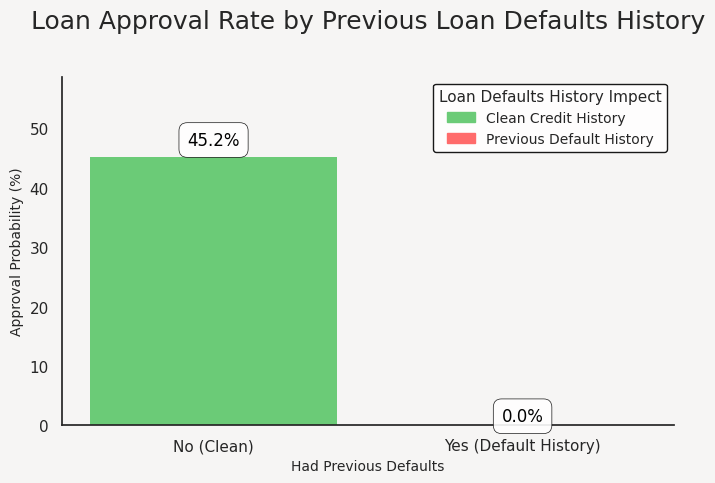

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Calculation: Approval rates per category
approval_rates = df.groupby('previous_loan_defaults')['loan_status'].mean() * 100
categories = ['No (Clean)', 'Yes (Default History)']
values = [approval_rates[0], approval_rates[1]]
colors = ['#6BCB77', '#FF6B6B']

# 2. Setup Figure and Background
plt.figure(figsize=(7, 5), facecolor='#F6F5F4')
ax = plt.gca()
ax.set_facecolor('#F6F5F4')

# 3. Create the Bars
bars = ax.bar(categories, values, color=colors, linewidth=0)

# 4. Add Data Labels using height * 1.03
for p in bars:
    height = p.get_height()
    label = f'{height:.1f}%'

    ax.text(
        p.get_x() + p.get_width()/2,
        height * 1.03,        # Position set to 103% of the bar height
        label,
        ha='center',
        va='bottom',
        fontsize=12,
        color='black',
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.5',
            linewidth=0.5,
            alpha=0.9
        )
    )

# 5. Add Legend with Frame, Title, and Border
clean_patch = mpatches.Patch(color='#6BCB77', label='Clean Credit History')
default_patch = mpatches.Patch(color='#FF6B6B', label='Previous Default History')

plt.legend(
    handles=[clean_patch, default_patch],
    loc='upper right',
    title='Loan Defaults History Impect',
    title_fontsize=11,
    fontsize=10,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.9
)

# 6. Titles and Axis Formatting
plt.title('Loan Approval Rate by Previous Loan Defaults History', fontsize=18, pad=35)
plt.xlabel('Had Previous Defaults', fontsize=10)
plt.ylabel('Approval Probability (%)', fontsize=10)

# 7. Final Aesthetic Cleanup
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Setting Y-limit to 130% of the max value to accommodate the lifted labels
plt.ylim(0, max(values) * 1.3)

plt.tight_layout()
plt.show()

Moreover, we see that a clean history increases the approval rates from 22.2% in the general dataset to 45.2% in this subgroup.

# Categorical Features

We use bar plots to visualize different categories in relation to the target variable (Loan Status). This analysis allows us to examine two key aspects:

1. Category Distribution: How applicants are distributed across different education levels, housing types, and loan purposes.

2. Impact on Approval Probability: The influence of each category on the likelihood of a loan being approved (=1) or rejected (=0).

Below is a summary of these categorical risk drivers.

Education: Approval rates are remarkably consistent across all levels at approximately 22%, indicating that education is not a primary factor for loan approval in this dataset.

Housing: Applicants who rent or fall under the "Other" category show the highest approval rates at about 33%, while homeowners and mortgage holders are approved significantly less often, ranging between 8% and 12%.

Loan Intent: The purpose of the loan plays a clear role. Debt Consolidation and Medical expenses lead with approval rates between 28% and 30%, whereas Venture loans have the lowest success rate at around 14%.

/tmp/ipython-input-3437781776.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipython-input-3437781776.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipython-input-3437781776.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


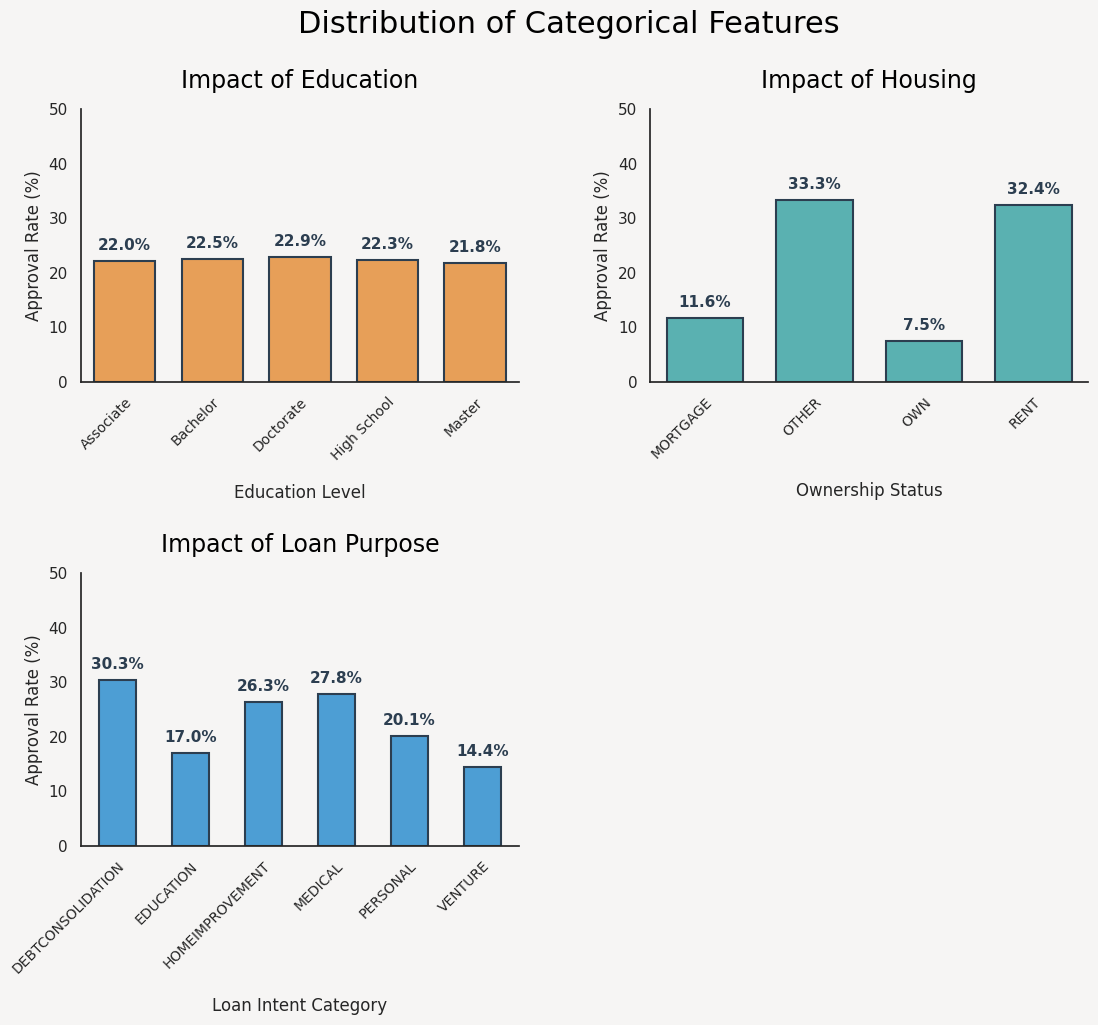

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Configuration
# Defining visual properties for each categorical plot
config = {
    'person_education': {
        'title': 'Impact of Education',
        'xlabel': 'Education Level',
        'color': '#FF9F40', # Orange
        'bar_width': 0.7
    },
    'person_home_ownership': {
        'title': 'Impact of Housing',
        'xlabel': 'Ownership Status',
        'color': '#4BC0C0', # Turquoise
        'bar_width': 0.7
    },
    'loan_intent': {
        'title': 'Impact of Loan Purpose',
        'xlabel': 'Loan Intent Category',
        'color': '#36A2EB', # Blue
        'bar_width': 0.5 # Extra spacing for the many categories in intent
    }
}

# Step 2: Figure Setup
# Using a slightly taller figure to accommodate the 50% scale zoom
fig = plt.figure(figsize=(13, 11), facecolor='#F6F5F4')

def draw_styled_bar(col_name, ax):
    """
    Groups data by category and draws a bar chart.
    """
    # Calculate percentage of approved loans per category
    data_subset = df.groupby(col_name)['loan_status'].mean().reset_index()
    data_subset['loan_status'] *= 100

    current_config = config[col_name]

    # Render the bars
    sns.barplot(
        x=col_name,
        y='loan_status',
        data=data_subset,
        ax=ax,
        color=current_config['color'],
        edgecolor='#2C3E50',
        linewidth=1.5,
        width=current_config['bar_width']
    )

    # Text styling
    ax.set_title(current_config['title'], fontsize=17, color='Black', pad=15)
    ax.set_xlabel(current_config['xlabel'], fontsize=12, labelpad=15)
    ax.set_ylabel("Approval Rate (%)", fontsize=12)
    ax.set_facecolor('#F6F5F4')

    # Y-Axis Optimization
    # Setting the limit to 50% to maximize the visual resolution of the data
    ax.set_ylim(0, 50)

    # X-Axis Label Refinement
    # Using 45-degree rotation and 'anchor' mode to ensure labels don't overlap
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha='right',
        rotation_mode='anchor',
        fontsize=10
    )

    # Annotate bars with the exact percentage
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold',
                    color='#2C3E50', xytext=(0, 6), textcoords='offset points')

    sns.despine(ax=ax)

# Step 3: Subplot Layout
ax1 = plt.subplot2grid((2, 2), (0, 0))
draw_styled_bar('person_education', ax1)

ax2 = plt.subplot2grid((2, 2), (0, 1))
draw_styled_bar('person_home_ownership', ax2)

ax3 = plt.subplot2grid((2, 2), (1, 0))
draw_styled_bar('loan_intent', ax3)

# Step 4: Final Spacing Adjustment
# Creating vertical symmetry between the title gap and the row gap
plt.suptitle('Distribution of Categorical Features',
             fontsize=22, color='Black', y=0.94)

# Adjusting hspace to match the visual 'weight' of the top margin
plt.subplots_adjust(top=0.85, hspace=0.7, wspace=0.3, bottom=0.18)

plt.show()

In [ ]:
# checking exact approval rates for each category
categorical_cols = ['person_education', 'person_home_ownership', 'loan_intent']

for col in categorical_cols:
    print(f"\n--- Approval Rates for {col} ---")
    report = df.groupby(col)['loan_status'].mean() * 100
    print(report.sort_values(ascending=False))


--- Approval Rates for person_education ---
person_education
Doctorate      22.866345
Bachelor       22.529113
High School    22.314119
Associate      22.035590
Master         21.762178
Name: loan_status, dtype: float64

--- Approval Rates for person_home_ownership ---
person_home_ownership
OTHER       33.333333
RENT        32.401877
MORTGAGE    11.598593
OWN          7.522874
Name: loan_status, dtype: float64

--- Approval Rates for loan_intent ---
loan_intent
DEBTCONSOLIDATION    30.272918
MEDICAL              27.819373
HOMEIMPROVEMENT      26.301484
PERSONAL             20.143027
EDUCATION            16.959895
VENTURE              14.433781
Name: loan_status, dtype: float64


# Distribution of applicants by educational background and gender

Graph Explanation:
This grouped bar chart displays the distribution of loan applicants across five education levels. Each category is segmented by gender (Male in  green, Female in coral), with percentage labels showing the gender split within each group.

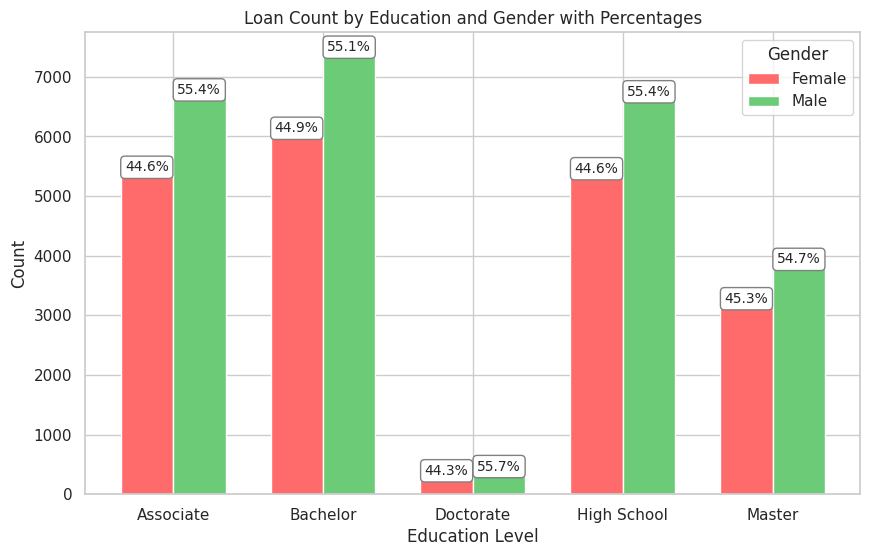

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set style with grid lines
sns.set_style("whitegrid")

# 1. Calculate counts by education level and gender
# Group data by education and gender
grouped = df.groupby(['person_education', 'person_gender'])
counts = grouped.size()
counts_by_education_gender = counts.unstack(fill_value=0)
# groupby - divides data by education + gender
# size() - counts records in each group
# unstack() - pivots gender into columns (female, male)
# fill_value=0 - handles missing combinations with 0 instead of NaN

# List of education levels
education_levels = counts_by_education_gender.index

# 2. Position columns on X axis
x = np.arange(len(education_levels))  # Position of each category
width = 0.35  # Width of each bar

# 3. Plot the bars
fig, ax = plt.subplots(figsize=(10,6))

# Bars for Females
bars_female = ax.bar(
    x - width/2,
    counts_by_education_gender['female'],
    width,
    label='Female',
    color='#FF6B6B'
)

# Bars for Males
bars_male = ax.bar(
    x + width/2,
    counts_by_education_gender['male'],
    width,
    label='Male',
    color='#6BCB77'
)

# 4. Add percentages above each bar
for i, edu in enumerate(education_levels):
    # Total count for the current education category
    total_in_category = counts_by_education_gender.loc[edu, 'female'] + counts_by_education_gender.loc[edu, 'male']

    # Female percentage
    percent_female = counts_by_education_gender.loc[edu, 'female'] / total_in_category * 100
    ax.text(
        x[i] - width/2,
        counts_by_education_gender.loc[edu, 'female'] + 1,  # Position slightly above the bar
        f'{percent_female:.1f}%',
        ha='center', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round', edgecolor='gray', facecolor='white')
    )

    # Male percentage
    percent_male = counts_by_education_gender.loc[edu, 'male'] / total_in_category * 100
    ax.text(
        x[i] + width/2,
        counts_by_education_gender.loc[edu, 'male'] + 1,
        f'{percent_male:.1f}%',
        ha='center', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round', edgecolor='gray', facecolor='white')
    )

# 5. Labels, Title, and Legend
ax.set_xticks(x)
ax.set_xticklabels(education_levels)
ax.set_ylabel("Count")
ax.set_xlabel("Education Level")
ax.set_title("Loan Count by Education and Gender with Percentages")
ax.legend(title='Gender')

# 6. Display the plot
plt.show()

Conclusions:

* Peak Demand: Bachelor degree holders represent
the largest applicant group (13,396), followed closely by Associate and High School levels.

* Gender Gap: There is a consistent male majority
(~ 55%) across the dataset compared to females (~45%), reflecting a higher loan application rate among men in all categories.

* Doctorate Segment: Applicants with a Doctorate have the lowest representation (only 621 applications), indicating a significantly smaller market share for this segment.

In [ ]:
# 1. Check loan application count by education level
print("Loan Applications by Education")
print(df['person_education'].value_counts())

print("\n" + "="*40 + "\n")

# 2. Check gender distribution (Count and Percentage)
print("Gender Distribution (Total)")
print(df['person_gender'].value_counts())

print("\nGender Percentages (Total)")
# normalize=True provides the proportion, multiplied by 100 for percentage
print(df['person_gender'].value_counts(normalize=True) * 100)

Loan Applications by Education
person_education
Bachelor       13396
Associate      12026
High School    11970
Master          6980
Doctorate        621
Name: count, dtype: int64


Gender Distribution (Total)
person_gender
male      24836
female    20157
Name: count, dtype: int64

Gender Percentages (Total)
person_gender
male      55.199698
female    44.800302
Name: proportion, dtype: float64


# Which type of loan intent is the most common among customers?

The most common loan intent is education, accounting for approximately 20.3% of all loans (9,151 cases). This is followed by medical and venture, with relatively similar proportions of 19.0% and 17.4%, respectively. The least common loan intent is home improvement, representing only 10.6% of the total loans (4,783 cases).

In [ ]:
df['loan_intent'].value_counts()

,count
loan_intent,
EDUCATION,9151
MEDICAL,8548
VENTURE,7815
PERSONAL,7551
DEBTCONSOLIDATION,7145
HOMEIMPROVEMENT,4783


Most loan intents have a similar share, between 7,000 and 9,000 applicants each. Education (9,151) and Medical (8,548) are the top categories, while Home Improvement (4,783) is the smallest group.

/tmp/ipython-input-1472424402.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


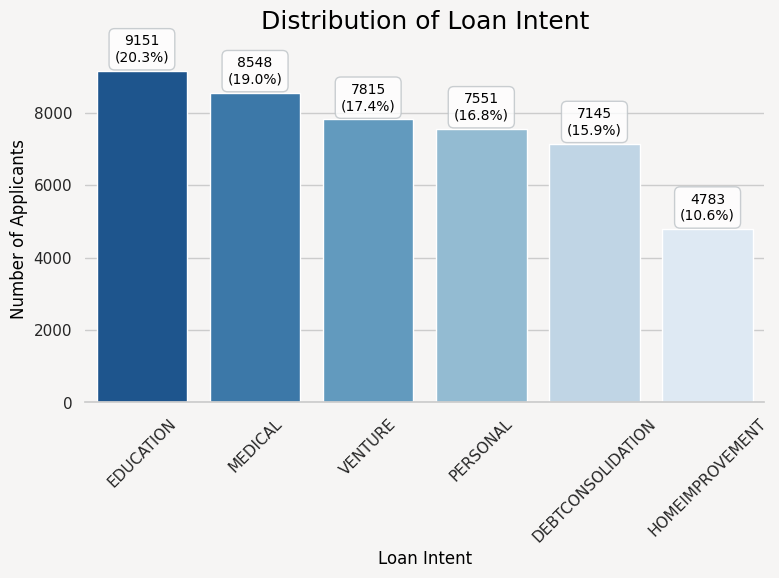

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Data Preparation
# Aggregate data to get counts for each loan intent category
intent_stats = df['loan_intent'].value_counts().reset_index()
intent_stats.columns = ['Loan Intent', 'Count']

# Calculate the relative percentage for each category to provide more context
total_loans = intent_stats['Count'].sum()
intent_stats['Percent'] = (intent_stats['Count'] / total_loans) * 100

# Step 2: Visual Style & Color Palette
# Setting a clean background style and matching the figure facecolor to a soft gray
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6), facecolor='#F6F5F4')

# Using 'YlGnBu_r' palette
# The '_r' suffix reverses the gradient so higher bars get darker colors
ax = sns.barplot(
    x='Loan Intent',
    y='Count',
    data=intent_stats,
    palette='Blues_r'
)

# Match the plot's inner background with the figure's facecolor
ax.set_facecolor('#F6F5F4')

# Step 3: Data Annotation (Adding Labels)
# Iterating through each bar (patch) to display the count and percentage on top
for p, percent in zip(ax.patches, intent_stats['Percent']):
    height = p.get_height()

    ax.text(
        x = p.get_x() + p.get_width() / 2, # Centering the text on the bar
        y = height + (intent_stats['Count'].max() * 0.02), # Dynamic offset above the bar
        s = f'{int(height)}\n({percent:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        color='black',
        # Adding a rounded white box (bbox) to ensure text readability against the grid
        bbox=dict(facecolor='white', edgecolor='#BDC3C7', boxstyle='round,pad=0.4', alpha=0.8)
    )

# Step 4: Titles and Axis Formatting
plt.title('Distribution of Loan Intent', fontsize=18, y=1.05, color='Black')
plt.xlabel('Loan Intent', fontsize=12, color='Black')
plt.ylabel('Number of Applicants', fontsize=12, color='Black')

# Rotating labels for better readability, especially for longer intent names
plt.xticks(rotation=45)

# Removing top, right, and left spines for a clean, modern "floating" appearance
sns.despine(left=True)

# Adjusting the layout to prevent label clipping
plt.tight_layout()
plt.show()

# Which home ownership category has the highest loan approval rate?

Even though the 'OTHER' category has the highest approval rate (33.3%), it only has 117 customers, so this number is slightly lessreliable. The 'RENT' category is much more reliable. It has a similar approval rate (32.4%) but includes 23,440 customers. This shows a clear trend: Renters are much more likely to get approved for a loan compared to homeowners or people with a mortgage

In [ ]:
home_loan_stats = df.groupby("person_home_ownership")["loan_status"].agg(['mean','count']).sort_values(by='mean', ascending=False)
home_loan_stats.rename(columns={'mean':'approval_rate','count':'num_customers'}, inplace=True)
home_loan_stats

,approval_rate,num_customers
person_home_ownership,,
OTHER,0.333333,117
RENT,0.324019,23440
MORTGAGE,0.115986,18485
OWN,0.075229,2951


Interestingly, approval rates among renters are relatively high. This may indicate that applicants without real estate tend to be more financially conservative. Thus, they often request smaller loans and are charged higher interest rates.

/tmp/ipython-input-2364880910.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=home_loan_stats.index, y=home_loan_stats['approval_rate_pct'], palette='Blues_r')


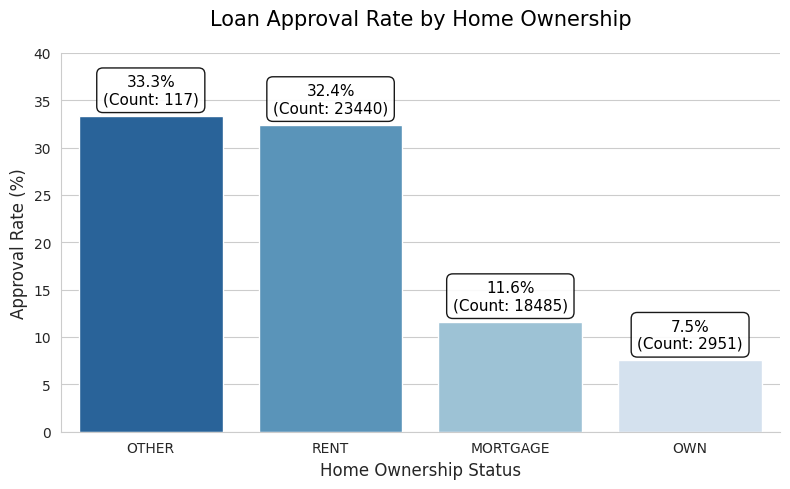

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert approval rate to percentage
home_loan_stats['approval_rate_pct'] = home_loan_stats['approval_rate'] * 100

# 2. Initialize the plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# 3. Create Bar Plot
# Using 'Blues_r' palette: Darker blue indicates higher approval rate
ax = sns.barplot(x=home_loan_stats.index, y=home_loan_stats['approval_rate_pct'], palette='Blues_r')

# 4. Add Annotations (Percentage + Customer Count)
for i in range(len(home_loan_stats)):
    rate = home_loan_stats['approval_rate_pct'].iloc[i]
    count = home_loan_stats['num_customers'].iloc[i]

    # Format label: 1st line = Percentage, 2nd line = Count
    label_text = f"{rate:.1f}%\n(Count: {int(count)})"

    # Place text slightly above the bar
    plt.text(x=i, y=rate + 1, s=label_text,
             ha='center', va='bottom', fontsize=11, color='Black',
             # Box styling: Round corners, white background, light grey edge, slight transparency
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="Black", alpha=0.9))

# 5. Final Styling
plt.title('Loan Approval Rate by Home Ownership',
          fontsize=15, color='Black', pad=20)
plt.ylabel('Approval Rate (%)', fontsize=12)
plt.xlabel('Home Ownership Status', fontsize=12)

# Set Y-axis limit to 40% (accommodating the max value of ~33% plus text)
plt.ylim(0, 40)

sns.despine()      # Remove top and right borders
plt.tight_layout() # Adjust layout to fit labels
plt.show()

# Loan Amount by Home Ownership

The data supports the connection between loan amounts and approval rates. The 'RENT' group, which enjoys the highest approval rate, requests the lowest average loan amount (~ 8,750).

In contrast, 'MORTGAGE' holders request significantly larger loans (~ 10,700), which increases the bank's risk exposure and likely contributes to their lower approval rates.

In [ ]:
# Check the average loan amount for each group
df.groupby('person_home_ownership')['loan_amount'].mean()

,loan_amount
person_home_ownership,
MORTGAGE,10718.014228
OTHER,11282.324786
OWN,8980.320230
RENT,8755.649403


/tmp/ipython-input-133041216.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=avg_loan_amount.index, y=avg_loan_amount.values, palette='Blues')


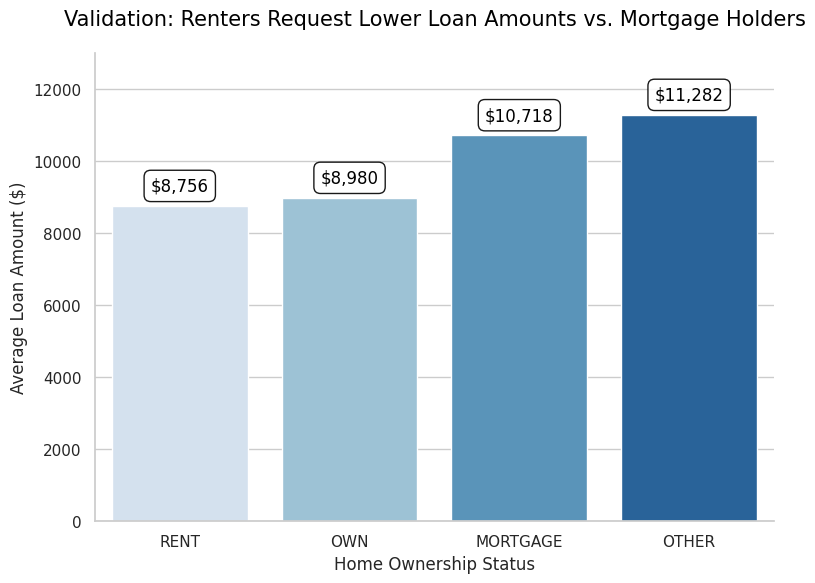

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Data Aggregation
# Group the dataset by home ownership status and calculate the mean loan amount for each.
# We sort the values to display the bars from lowest amount to highest amount.
avg_loan_amount = df.groupby('person_home_ownership')['loan_amount'].mean().sort_values()

# Step 2: Plot Configuration
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")  # Sets a clean background with gridlines for easier reading

# Step 3: Creating the Bar Plot
# x: The categories (Rent, Own, etc.)
# y: The average loan amount
# palette='Blues': Uses a sequential color gradient.
# Lighter blue indicates lower loan amounts, darker blue indicates higher amounts.
ax = sns.barplot(x=avg_loan_amount.index, y=avg_loan_amount.values, palette='Blues')

# Step 4: Adding Annotated Text Boxes
# Loop through each bar to add the exact dollar amount on top
for i in range(len(avg_loan_amount)):
    amount = avg_loan_amount.values[i]

    # Format the number as currency (e.g., 8755 becomes "$8,755")
    # {:,.0f} means: add comma separators and use 0 decimal places
    label_text = f"${amount:,.0f}"

    # Place the text on the graph
    plt.text(
        x=i,                        # Horizontal position (center of the bar)
        y=amount + 300,             # Vertical position (slightly above the bar)
        s=label_text,               # The text to display
        ha='center', va='bottom',   # Align text: Center horizontally, Bottom vertically
        fontsize=12, color='Black',
        # Box styling: Rounded corners, white fill, grey edge, slight transparency
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="Black", alpha=0.9)
    )

# Step 5: Final Styling and Labels
# Title highlights the key insight: Renters ask for less money
plt.title('Validation: Renters Request Lower Loan Amounts vs. Mortgage Holders',
          fontsize=15, color='Black', pad=20)

plt.ylabel('Average Loan Amount ($)', fontsize=12)
plt.xlabel('Home Ownership Status', fontsize=12)

# Increase Y-axis limit to ensure the text boxes are not cut off at the top
plt.ylim(0, 13000)

sns.despine()      # Remove the top and right border spines for a cleaner aesthetic
plt.tight_layout() # Automatically adjust subplot params so the plot fits into the figure area
plt.show()

# Do we have enough data to draw reliable conclusions about the link between housing and loan intent?

We have thousands of applicants for Rent and Mortgage, which is great.

Note: The 'Other' group is very small, so we won't rely on its results too much.

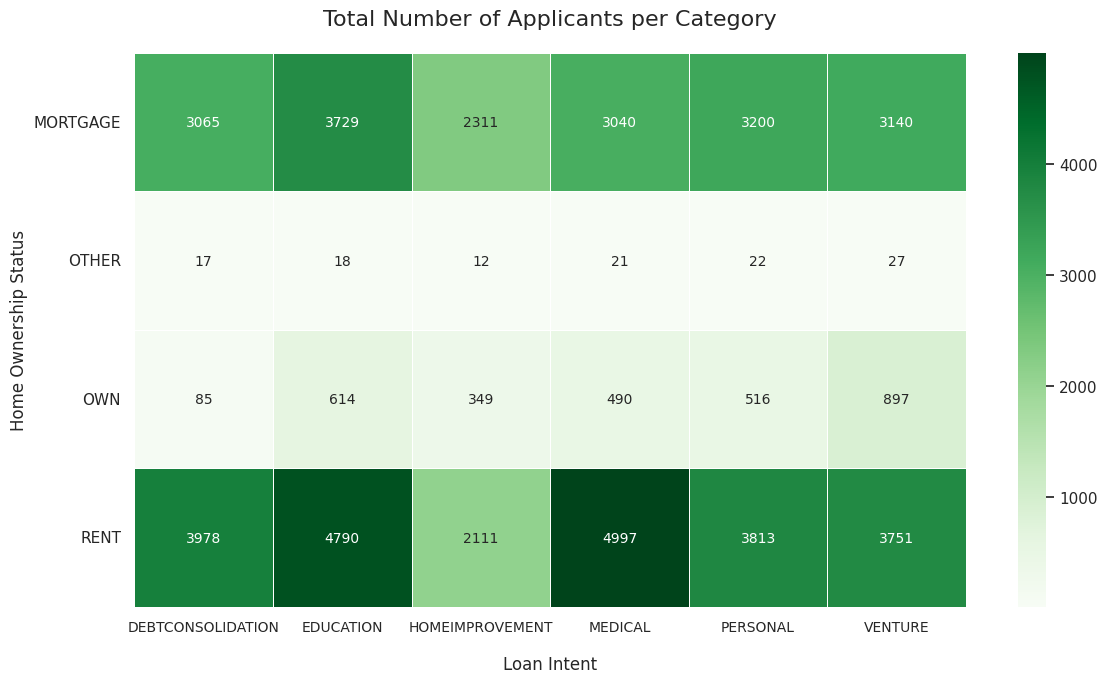

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the count table (total applicants per category)
sample_size_table = df.pivot_table(index='person_home_ownership',
                                   columns='loan_intent',
                                   values='loan_status',
                                   aggfunc='count')

# Set figure size for horizontal readability
plt.figure(figsize=(12, 7))

# Use Greens to signal 'Volume' and 'd' for whole numbers
sns.heatmap(
    sample_size_table,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=.5,
    annot_kws={"size": 10}
)

# Axis formatting: Straight labels for clarity
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0)

# Title and labels
plt.title('Total Number of Applicants per Category', fontsize=16, pad=20)
plt.xlabel('Loan Intent', fontsize=12, labelpad=15)
plt.ylabel('Home Ownership Status', fontsize=12)

plt.tight_layout()
plt.show()

Graph Explanation: This graph shows how many people applied for a loan in each category. As we can see, the Rent and Mortgage groups have thousands of applicants per cell. This tells us that our findings for these groups are very strong and reliable. However, the 'Other' group is quite small (less than 30 people), so we should be careful with its results.

# How does the combination of housing status and loan purpose affect a person's chance of getting his loan approved?

Graph Explanation: This heatmap shows the actual approval percentages (from 0.00 to 1.00). Darker blue means a higher chance of approval. It helps us to see which combinations are considered 'safe' or 'risky' by the bank.

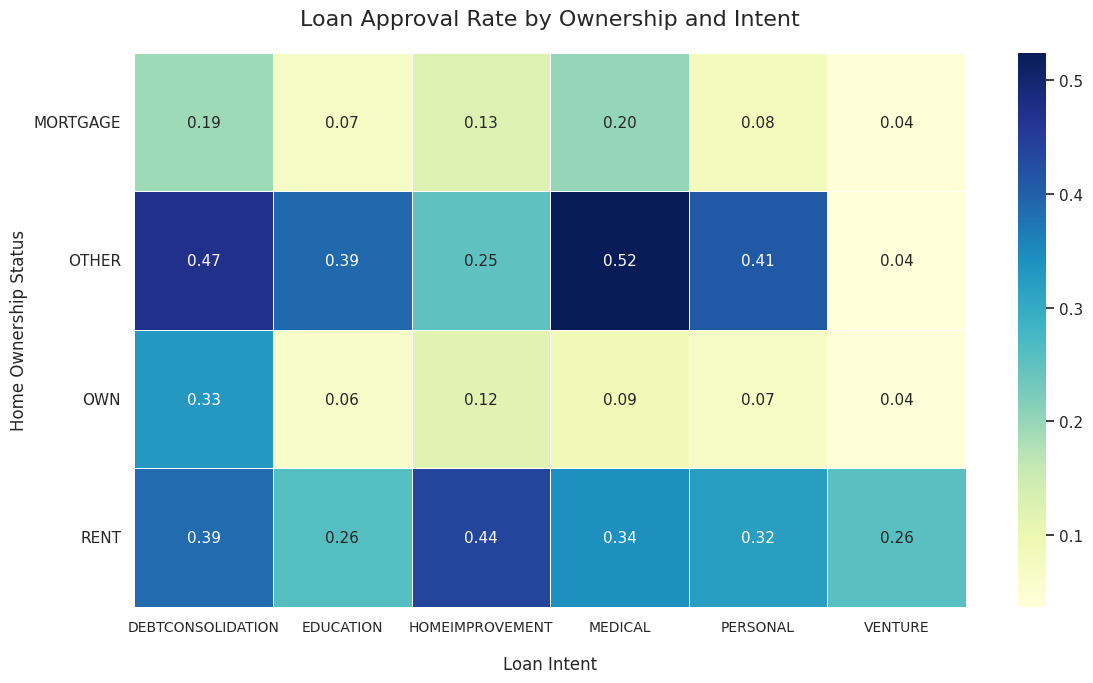

In [ ]:
# Create the mean table (approval percentage as a decimal)
pivot_table = df.pivot_table(index='person_home_ownership',
                             columns='loan_intent',
                             values='loan_status',
                             aggfunc='mean')

# Keep the same figure size for visual consistency
plt.figure(figsize=(12, 7))

# Use YlGnBu for rates and .2f for decimal precision
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=.5,
    annot_kws={"size": 11}
)

# Axis formatting: Straight labels
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0)

# Title and labels
plt.title('Loan Approval Rate by Ownership and Intent', fontsize=16, pad=20)
plt.xlabel('Loan Intent', fontsize=12, labelpad=15)
plt.ylabel('Home Ownership Status', fontsize=12)

plt.tight_layout()
plt.show()

* Renters & Home Improvement: Renters have a surprisingly high approval rate of 44% for Home Improvement loans. This is one of the highest rates in the entire dataset.
* The Mortgage-Venture subgroup: Mortgage holders face the toughest challenge, with only a 4% approval rate for 'Venture' loans. This is the lowest point in the chart, showing that banks are very cautious with this combination.
* Final Insight: Overall, the combination of housing status and loan purpose is critical. While both matter, having a mortgage often acts as a "ceiling" that limits the chances of approval regardless of the loan's purpose.

# Summary and Conclusions: Risk Profile and Key Drivers

1. The Housing Paradox: Renters have higher approval rates (~ 33%) than mortgage holders (~10%) simply because they request smaller loan amounts. Risk is driven by exposure size, not ownership.

2. The Age "U-Curve": Approval rates peak for older adults (50+, high stability) and young adults, while dipping for the 30-40 age group (high expenses).

3. Loan Intent: "Debt Consolidation" is the safest purpose for approval; "Venture" loans are the riskiest (~14% approval).

4. Education: A non-factor. Approval rates remain consistent (~22%) regardless of education level.

5. Credit History (The Deal-Breaker): A prior default record is the strongest barrier to approval. Applicants with a history of default are almost universally rejected, regardless of other factors.



Bottom Line: The bank is highly conservative regarding credit history and loan amounts, but flexible on demographics. The ideal borrower has a clean credit history, is over 50, and requests a small amount for debt consolidation. Approval rates further increase as the applicant is willing to pay higher interest rates.

# Strategic Recommendations & Future Research

1. Recommendations for Action:

* "Second Chance" Program: Instead of automatic rejection based on past defaults, re-evaluate applicants based on their current financial stability. Creating a specific track for rehabilitated borrowers could open a new market.

* Target the 50+ Segment: Our analysis identified the 50+ age group as a "High Approval / Low Volume" niche. We recommend a targeted marketing campaign to attract more of these safe, high-quality borrowers.

2.  Future Research
* Data Reality Check: Since this is a synthetic dataset, some patterns contradict real world banking logic. Future analysis should be validated with real bank data.

* Combining Factors: It would be useful to analyze Age and Marital Status together. For example, a single 30 years old likely behaves differently than a married 30 years old with children.

* Missing Financial Details: The dataset lists Income but not Expenses. To better assess risk, future analysis needs data on the borrower's monthly expenses and other existing debts.